# Target progress

The per-target summary answers "how is each target doing": requested time, schedule outcomes, and (once quality reports flow) the three science counters: `success_observations` (a partial counts as its usable fraction), `success_hours`, and `n_success_days`. Exoplanet targets additionally get `n_transits_observed` when a `PandoraTargetList` checkout is configured (`target_list_dir` in the config file).

In [1]:
from pandoraobservations.cache import load_target_summary

summary = load_target_summary()
print(f"{len(summary)} targets, columns: {list(summary.columns)}")
summary.head(10)

30 targets, columns: ['target', 'n_observations', 'requested_hours', 'n_requested_days', 'max_priority', 'first_start_utc', 'last_stop_utc', 'success_observations', 'success_hours', 'n_success_days', 'n_dropped', 'n_scheduled', 'n_truncated']


,target,n_observations,requested_hours,n_requested_days,max_priority,first_start_utc,last_stop_utc,success_observations,success_hours,n_success_days,n_dropped,n_scheduled,n_truncated
target_key,,,,,,,,,,,,,
hd_189733b,HD_189733b,44,33.316667,5,2,2026-08-25 18:01:00,2026-08-31 00:30:00,0.0,0.0,0,0,39,5
toi_4527b,TOI-4527b,16,13.350000,3,2,2026-08-25 01:29:00,2026-08-30 02:31:00,0.0,0.0,0,0,16,0
toi_181b,TOI-181b,15,13.050000,1,2,2026-08-24 00:59:00,2026-08-25 00:11:00,0.0,0.0,0,0,12,3
g4476152832143994112,G4476152832143994112,23,6.100000,2,0,2026-08-24 00:14:00,2026-08-25 15:13:00,0.0,0.0,0,0,22,1
k2_141b,K2-141b,8,5.350000,2,2,2026-08-26 22:26:00,2026-08-27 10:27:00,0.0,0.0,0,0,8,0
trappist_1,TRAPPIST-1,9,5.116667,2,0,2026-08-25 00:11:00,2026-08-26 21:34:00,0.0,0.0,0,1,6,2
g4495705069464896000,G4495705069464896000,12,3.916667,2,0,2026-08-27 04:08:00,2026-08-29 16:03:00,0.0,0.0,0,0,12,0
wolf_940,Wolf_940,6,3.900000,1,0,2026-08-29 07:21:00,2026-08-29 20:31:00,0.0,0.0,0,0,3,3
g294135823040394752,G294135823040394752,15,3.900000,2,0,2026-08-25 18:53:00,2026-08-26 17:44:00,0.0,0.0,0,0,14,1


The `n_<status>` columns count observations by lifecycle state. Until quality reports are ingested everything sits at `SCHEDULED`/`TRUNCATED`/`DROPPED` (or `REQUESTED` before the sequence arrives), and the success counters stay at zero.

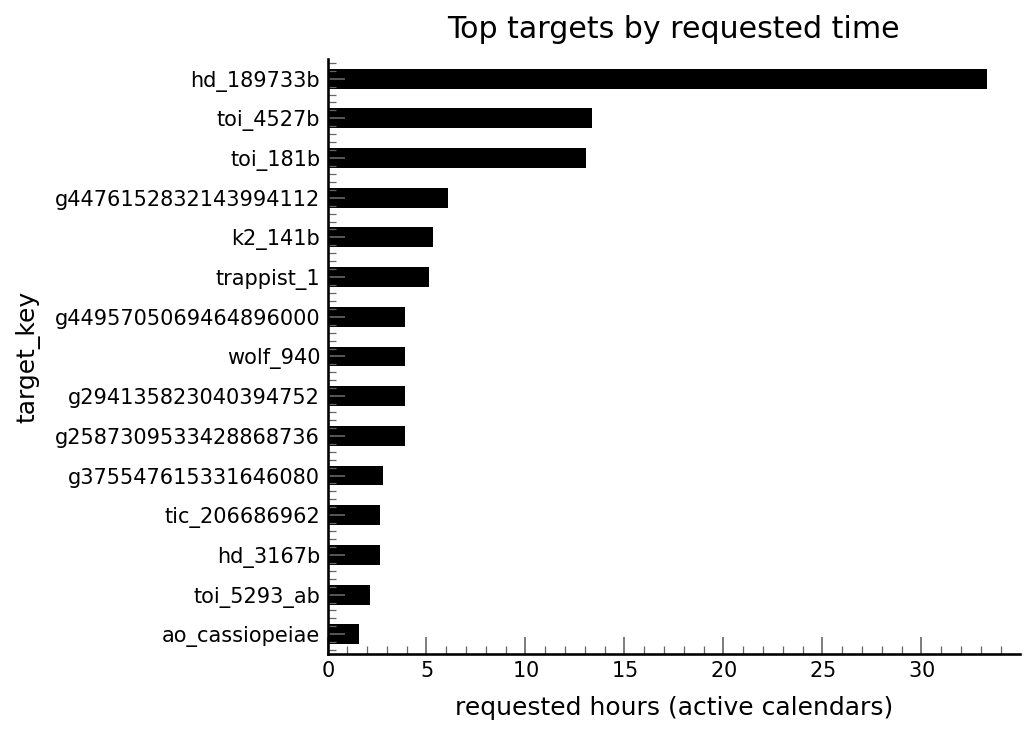

In [2]:
import matplotlib.pyplot as plt

from pandoraobservations import PANDORASTYLE

with plt.style.context(PANDORASTYLE):
    ax = summary["requested_hours"].head(15).plot.barh(figsize=(7, 5))
    ax.invert_yaxis()
    ax.set_xlabel("requested hours (active calendars)")
    ax.set_title("Top targets by requested time")